# Project Title
## Predicting Daily Stock Returns with a Multi-Layer Perceptron (MLP)

This notebook builds a beginner-friendly machine learning project that predicts the next day's stock return using past daily return values as input features.
We will use a Multi-Layer Perceptron (MLP) regressor from scikit-learn and compare several model configurations to understand how architecture and training effort affect performance.

## Introduction

The goal is to predict the next day's daily return using historical return patterns. Since the problem is time-series forecasting, we must maintain chronological order and split the dataset into training and testing periods without shuffling.

We will analyze one stock: ABUK.HR (Abu Qir Fertilizers). If Yahoo Finance is unavailable or the ticker is not found, the notebook will automatically fall back to another stock symbol.

The model uses lagged returns as features, such as previous 1-day, 2-day, 3-day, and 5-day returns.

## Import Libraries

The following libraries are needed for data download, preprocessing, modeling, evaluation, and plotting.

In [1]:
# If libraries are missing, install them with these commands:
# !pip install yfinance pandas numpy matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Optional: improves display quality in notebooks
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Data Collection

We download historical daily price data from Yahoo Finance using the yfinance package.
We select a stock ticker, then fetch a long enough time period to make the model useful.

In [2]:
# Choose a stock for analysis.
# We use a reliable public ticker for Yahoo Finance access.
candidate_tickers = ["AAPL"]


def download_stock_data(tickers, start_date="2015-01-01", end_date="2024-12-31"):
    """Download stock data from Yahoo Finance one ticker at a time."""
    for ticker in tickers:
        try:
            df = yf.download(
                ticker,
                start=start_date,
                end=end_date,
                progress=False,
                auto_adjust=True,
                actions=False,
            )

            if df is None or df.empty:
                continue

            if isinstance(df.columns, pd.MultiIndex):
                if "Close" in df.columns.get_level_values(0):
                    df = df["Close"]
                elif "Adj Close" in df.columns.get_level_values(0):
                    df = df["Adj Close"]
                else:
                    continue

            if isinstance(df, pd.DataFrame) and df.shape[1] == 1:
                df.columns = ["close"]

            if isinstance(df, pd.Series):
                df = df.to_frame(name="close")

            df = df.reset_index().copy()
            df.columns = [str(c).lower() for c in df.columns]

            if "date" not in df.columns and "datetime" in df.columns:
                df = df.rename(columns={"datetime": "date"})
            if "close" not in df.columns and "adj close" in df.columns:
                df = df.rename(columns={"adj close": "close"})
            if "close" not in df.columns:
                continue

            df = df[["date", "close"]].copy()
            df["date"] = pd.to_datetime(df["date"])
            df["close"] = pd.to_numeric(df["close"], errors="coerce")
            df = df.dropna(subset=["date", "close"]).sort_values("date").reset_index(drop=True)
            df["ticker"] = ticker
            print(f"Successfully downloaded data for {ticker}")
            return df

        except Exception as exc:
            print(f"Ticker {ticker} failed: {exc}")

    raise ValueError("No stock data could be downloaded for the provided tickers.")


stock_df = download_stock_data(candidate_tickers)
stock_df.head()

Successfully downloaded data for AAPL


,date,close,ticker
0,2015-01-02,24.171757,AAPL
1,2015-01-05,23.490797,AAPL
2,2015-01-06,23.493008,AAPL
3,2015-01-07,23.822437,AAPL
4,2015-01-08,24.737747,AAPL


## Exploratory Data Analysis

Now we inspect the downloaded data to understand the price series and ensure the columns look correct.

In [3]:
# Keep the date and close price columns for our analysis.
# If the downloaded data uses a different naming convention, unify it.
if 'close' not in stock_df.columns:
    stock_df['close'] = stock_df['adj close'] if 'adj close' in stock_df.columns else stock_df['Close']

if 'date' not in stock_df.columns:
    stock_df = stock_df.rename(columns={'Date': 'date'})

stock_df['date'] = pd.to_datetime(stock_df['date'])
stock_df = stock_df.sort_values('date').reset_index(drop=True)

print(f"Rows: {len(stock_df)}")
print(f"Date range: {stock_df['date'].min()} to {stock_df['date'].max()}")
print(f"Columns: {list(stock_df.columns)}")

stock_df[['date', 'close']].head()

Rows: 2515
Date range: 2015-01-02 00:00:00 to 2024-12-30 00:00:00
Columns: ['date', 'close', 'ticker']


,date,close
0,2015-01-02,24.171757
1,2015-01-05,23.490797
2,2015-01-06,23.493008
3,2015-01-07,23.822437
4,2015-01-08,24.737747


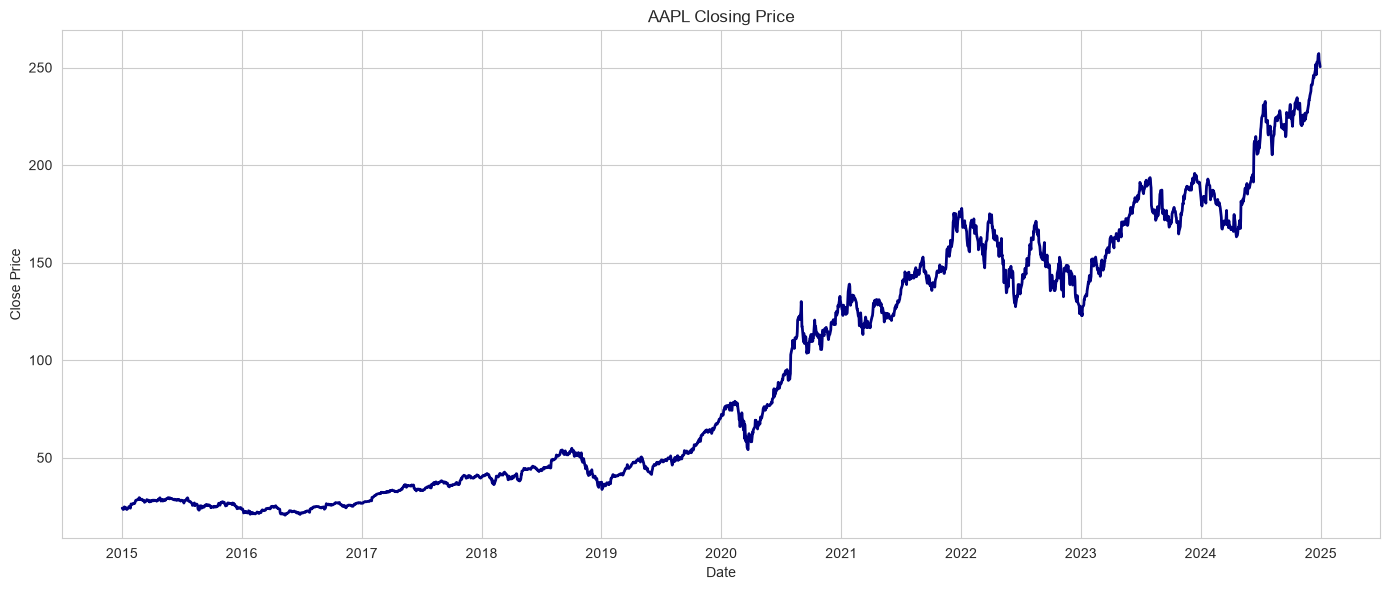

In [4]:
# Plot the closing price to inspect the overall movement.
plt.figure(figsize=(14, 6))
plt.plot(stock_df['date'], stock_df['close'], color='navy', linewidth=2)
plt.title(f"{stock_df['ticker'].iloc[0]} Closing Price")
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.tight_layout()
plt.show()

## Feature Engineering

We will compute daily returns and create lag features based on the historical return values.
The target is the next day's return.

In [5]:
# Compute daily returns from closing price.
# Formula: (Close_t / Close_{t-1}) - 1
data = stock_df[['date', 'close']].copy()
data['Daily_Return'] = data['close'].pct_change()

# Create lag features to predict the next day return.
for lag in [1, 2, 3, 5]:
    data[f'Return_Lag_{lag}'] = data['Daily_Return'].shift(lag)

# The target is tomorrow's daily return.
data['Target_Return'] = data['Daily_Return'].shift(-1)

# Remove rows with missing values introduced by shifting.
data = data.dropna().reset_index(drop=True)

print(data.head())
print(f"Rows after feature engineering: {len(data)}")

        date      close  Daily_Return  Return_Lag_1  Return_Lag_2  \
0 2015-01-12  24.154070     -0.024641      0.001072      0.038422   
1 2015-01-13  24.368528      0.008879     -0.024641      0.001072   
2 2015-01-14  24.275671     -0.003811      0.008879     -0.024641   
3 2015-01-15  23.616821     -0.027140     -0.003811      0.008879   
4 2015-01-16  23.433308     -0.007770     -0.027140     -0.003811   

   Return_Lag_3  Return_Lag_5  Target_Return  
0      0.014022     -0.028172       0.008879  
1      0.038422      0.000094      -0.003811  
2      0.001072      0.014022      -0.027140  
3     -0.024641      0.038422      -0.007770  
4      0.008879      0.001072       0.025758  
Rows after feature engineering: 2508


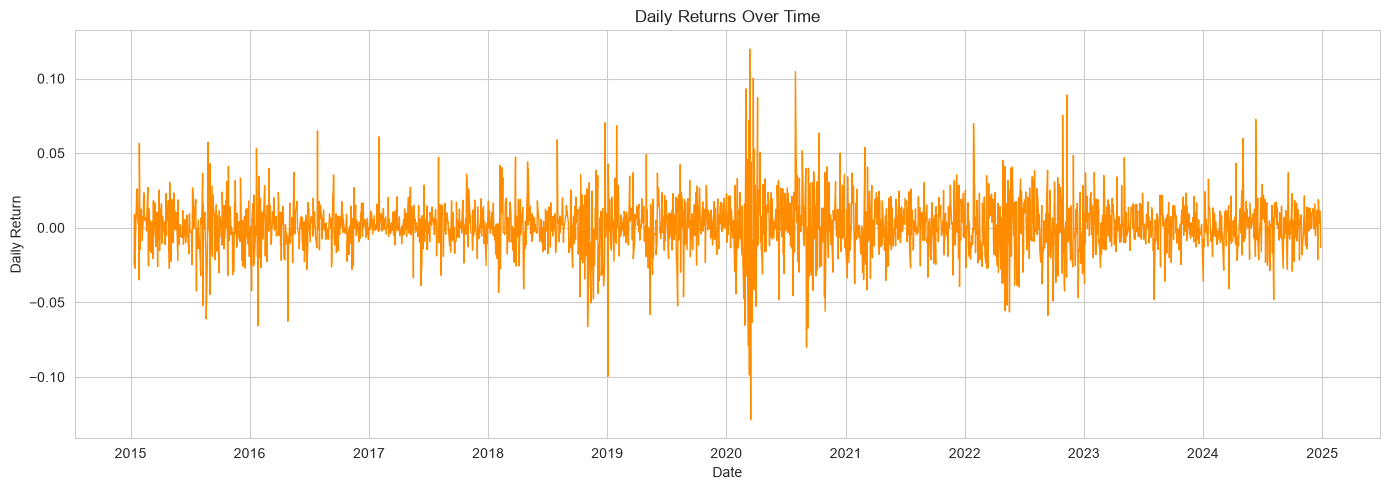

In [6]:
# Plot the return series for a quick view of the data distribution.
plt.figure(figsize=(14, 5))
plt.plot(data['date'], data['Daily_Return'], color='darkorange', linewidth=1)
plt.title('Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.tight_layout()
plt.show()

## Data Preprocessing

We keep only the engineered features and target variable for modeling.
This step also ensures the data is ready for a time-based train/test split.

In [7]:
feature_columns = [
    'Return_Lag_1',
    'Return_Lag_2',
    'Return_Lag_3',
    'Return_Lag_5',
]

X = data[feature_columns].copy()
y = data['Target_Return'].copy()

# Check for NaN values in the features and target.
print(f"Missing values in X: {X.isnull().sum().sum()}")
print(f"Missing values in y: {y.isnull().sum()}")

# Final safety check: remove any remaining NaNs.
X = X.dropna()
y = y.loc[X.index]
data = data.loc[X.index]

Missing values in X: 0
Missing values in y: 0


## Train/Test Split (70/30)

Because this is time series data, we must split chronologically.
The first 70% of the data is used for training and the last 30% for testing.

In [8]:
# Use a chronological split with no random shuffling.
split_index = int(len(X) * 0.70)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Train date range: {data['date'].iloc[0]} to {data['date'].iloc[split_index-1]}")
print(f"Test date range: {data['date'].iloc[split_index]} to {data['date'].iloc[-1]}")

Train samples: 1755
Test samples: 753
Train date range: 2015-01-12 00:00:00 to 2021-12-29 00:00:00
Test date range: 2021-12-30 00:00:00 to 2024-12-27 00:00:00


## Feature Scaling

MLP models work better when input features are on a similar scale. We apply StandardScaler only to the feature matrix.

In [9]:
# Standardize the input features using the training set only.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete")
print(pd.DataFrame(X_train_scaled, columns=feature_columns).describe().round(3).head())

Feature scaling complete
       Return_Lag_1  Return_Lag_2  Return_Lag_3  Return_Lag_5
count      1755.000      1755.000      1755.000      1755.000
mean         -0.000         0.000         0.000         0.000
std           1.000         1.000         1.000         1.000
min          -7.110        -7.103        -7.105        -7.100
25%          -0.429        -0.430        -0.430        -0.429


## Building the MLP Model

A Multi-Layer Perceptron regressor is a neural network for regression tasks. It can learn nonlinear relationships between the lagged returns and the next return.

We will start with a baseline configuration and compare several experiments later.

In [10]:
baseline_model = MLPRegressor(
    hidden_layer_sizes=(50,),
    max_iter=500,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    learning_rate_init=0.001,
    activation='relu'
)

print(baseline_model)

MLPRegressor(early_stopping=True, hidden_layer_sizes=(50,), max_iter=500,
             n_iter_no_change=20, random_state=42)


## Model Training

Train the baseline model using the training set.
The model learns from past lagged returns to predict the next day return.

In [11]:
baseline_model.fit(X_train_scaled, y_train)

# Generate predictions on the test set.
y_pred = baseline_model.predict(X_test_scaled)

print("Training completed.")
print(f"Final training loss: {baseline_model.loss_}")

Training completed.
Final training loss: 0.0001463839039435683


## Model Evaluation

We evaluate the model using standard regression metrics: MSE, MAE, and R².

In [12]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.8f}")
print(f"Mean Absolute Error (MAE): {mae:.8f}")
print(f"R-squared (R²): {r2:.8f}")

baseline_metrics = {
    'Model Configuration': 'hidden_layer_sizes=(50,), max_iter=500',
    'Number of layers': 1,
    'Number of neurons': 50,
    'Epochs / max_iter': 500,
    'MSE': mse,
    'MAE': mae,
    'R²': r2
}
baseline_metrics

Mean Squared Error (MSE): 0.00040669
Mean Absolute Error (MAE): 0.01516029
R-squared (R²): -0.39635777


{'Model Configuration': 'hidden_layer_sizes=(50,), max_iter=500',
 'Number of layers': 1,
 'Number of neurons': 50,
 'Epochs / max_iter': 500,
 'MSE': 0.0004066947249635347,
 'MAE': 0.015160292446152397,
 'R²': -0.3963577722844758}

## Visualization of Results

We now visualize the actual returns compared with predictions.

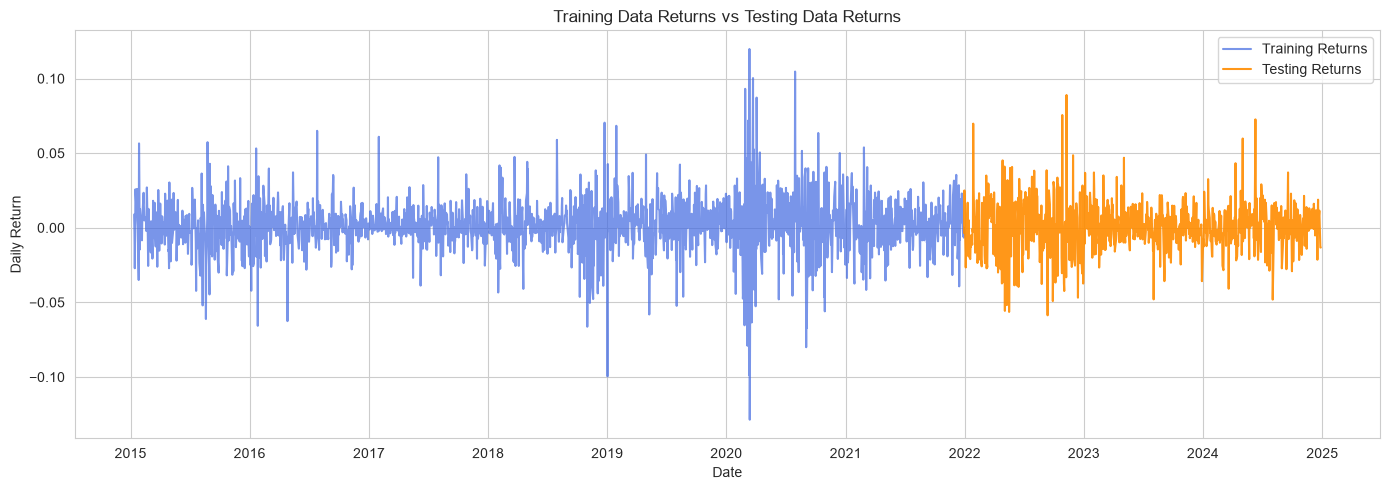

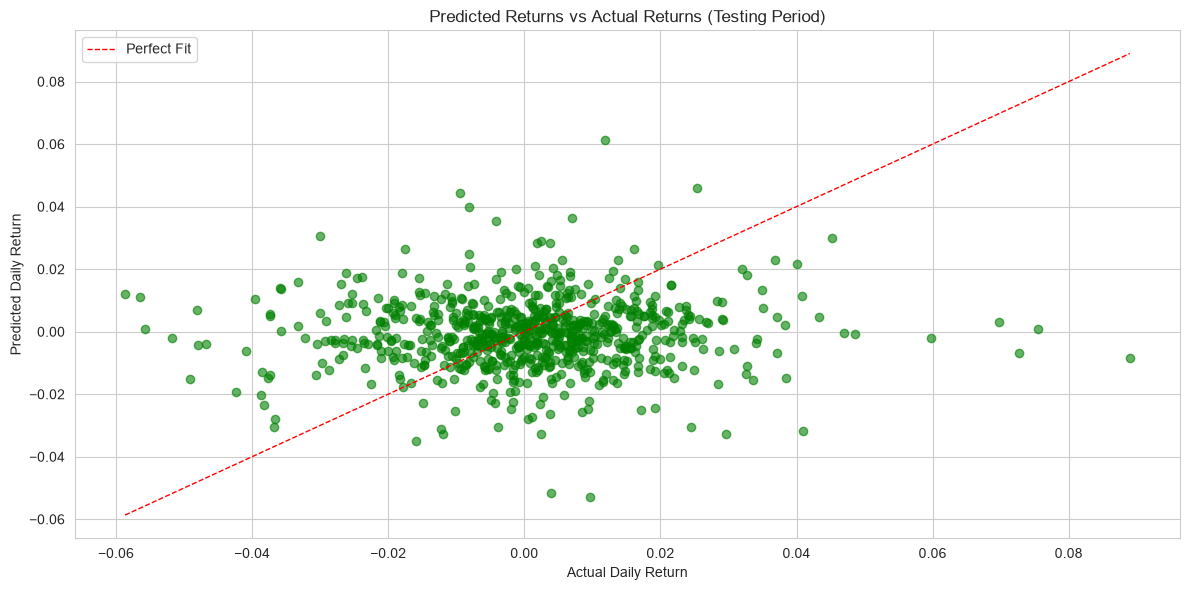

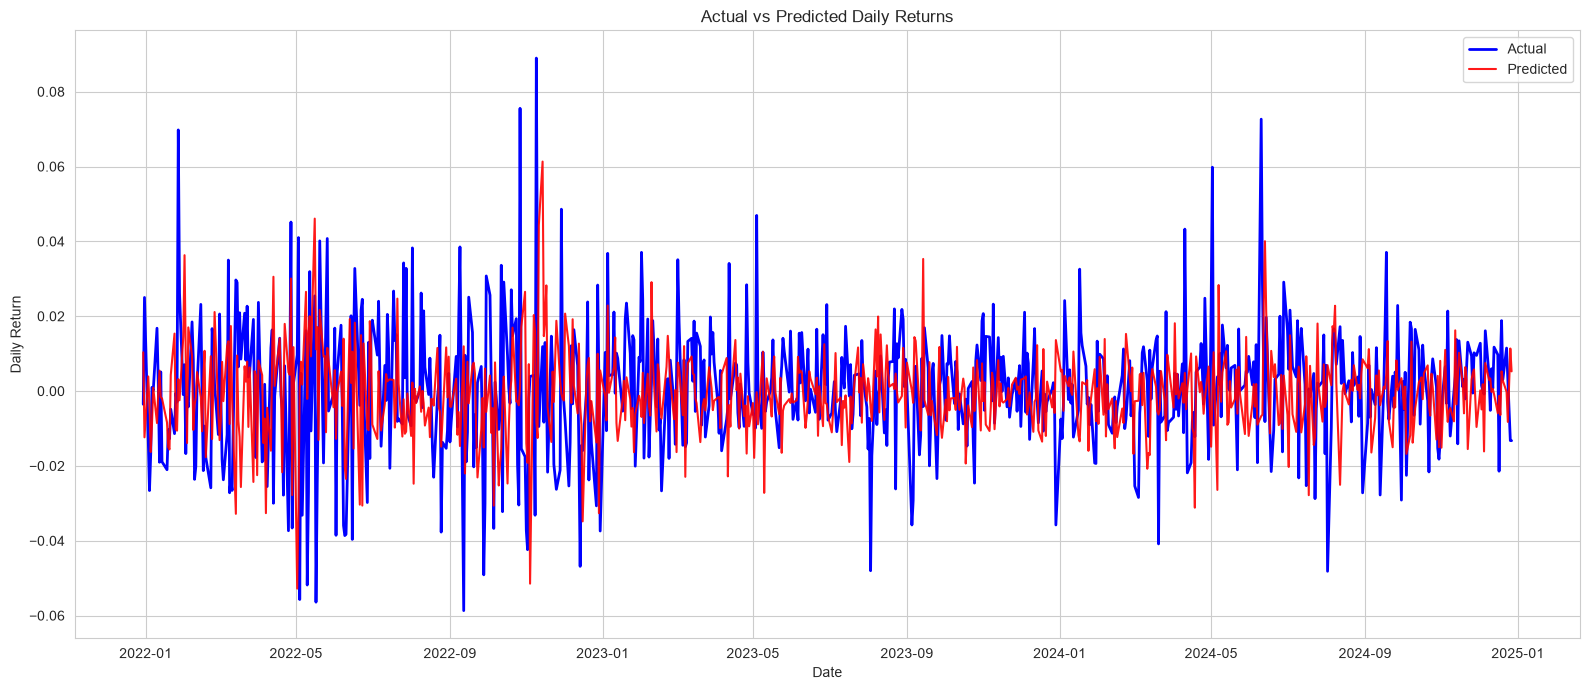

In [13]:
# Create a DataFrame for evaluation plots.
results_df = pd.DataFrame({
    'Actual_Returns': y_test.values,
    'Predicted_Returns': y_pred
})

# 1) Training data returns vs Testing data returns
plt.figure(figsize=(14, 5))
plt.plot(data['date'].iloc[:split_index], y.iloc[:split_index], label='Training Returns', color='royalblue', alpha=0.7)
plt.plot(data['date'].iloc[split_index:], y.iloc[split_index:], label='Testing Returns', color='darkorange', alpha=0.9)
plt.title('Training Data Returns vs Testing Data Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.tight_layout()
plt.show()

# 2) Predicted returns vs actual returns for the testing period
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=1, label='Perfect Fit')
plt.title('Predicted Returns vs Actual Returns (Testing Period)')
plt.xlabel('Actual Daily Return')
plt.ylabel('Predicted Daily Return')
plt.legend()
plt.tight_layout()
plt.show()

# 3) Clear line chart comparing actual vs predicted returns
plt.figure(figsize=(16, 7))
test_dates = data['date'].iloc[split_index:]
plt.plot(test_dates, y_test.values, label='Actual', color='blue', linewidth=2)
plt.plot(test_dates, y_pred, label='Predicted', color='red', linewidth=1.5, alpha=0.9)
plt.title('Actual vs Predicted Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.tight_layout()
plt.show()

## Experiments

We compare several MLP configurations to study the effect of epochs, hidden layer count, and number of neurons.

The following experiments are evaluated:
- Experiment 1: hidden_layer_sizes=(10,), max_iter=500
- Experiment 2: hidden_layer_sizes=(50,), max_iter=500
- Experiment 3: hidden_layer_sizes=(50, 25), max_iter=500
- Experiment 4: hidden_layer_sizes=(100, 50, 25), max_iter=1000

In [14]:
def evaluate_model(hidden_layer_sizes, max_iter=500, random_state=42):
    """Train an MLP model and report key evaluation metrics."""
    model = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        max_iter=max_iter,
        random_state=random_state,
        early_stopping=True,
        n_iter_no_change=20,
        learning_rate_init=0.001,
        activation='relu'
    )

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        'hidden_layer_sizes': hidden_layer_sizes,
        'number_of_layers': len(hidden_layer_sizes),
        'number_of_neurons': sum(hidden_layer_sizes),
        'max_iter': max_iter,
        'MSE': mse,
        'MAE': mae,
        'R²': r2,
        'model': model,
        'predictions': y_pred
    }

experiments = [
    {'name': 'Experiment 1', 'hidden_layer_sizes': (10,), 'max_iter': 500},
    {'name': 'Experiment 2', 'hidden_layer_sizes': (50,), 'max_iter': 500},
    {'name': 'Experiment 3', 'hidden_layer_sizes': (50, 25), 'max_iter': 500},
    {'name': 'Experiment 4', 'hidden_layer_sizes': (100, 50, 25), 'max_iter': 1000},
]

experiment_results = []
for experiment in experiments:
    result = evaluate_model(
        hidden_layer_sizes=experiment['hidden_layer_sizes'],
        max_iter=experiment['max_iter']
    )
    result['name'] = experiment['name']
    experiment_results.append(result)
    print(f"\n{experiment['name']} completed")
    print(f"Configuration: {experiment['hidden_layer_sizes']}, max_iter={experiment['max_iter']}")
    print(f"MSE: {result['MSE']:.8f}")
    print(f"MAE: {result['MAE']:.8f}")
    print(f"R²: {result['R²']:.8f}")


Experiment 1 completed
Configuration: (10,), max_iter=500
MSE: 0.00050531
MAE: 0.01671633
R²: -0.73493973

Experiment 2 completed
Configuration: (50,), max_iter=500
MSE: 0.00040669
MAE: 0.01516029
R²: -0.39635777

Experiment 3 completed
Configuration: (50, 25), max_iter=500
MSE: 0.00043687
MAE: 0.01563944
R²: -0.49996899

Experiment 4 completed
Configuration: (100, 50, 25), max_iter=1000
MSE: 0.00043293
MAE: 0.01540854
R²: -0.48642405


## Comparison of Experiments

We summarize all model configurations in a comparison table.

In [15]:
comparison_df = pd.DataFrame([{
    'Model Configuration': exp['name'],
    'Hidden Layer Sizes': exp['hidden_layer_sizes'],
    'Number of layers': exp['number_of_layers'],
    'Number of neurons': exp['number_of_neurons'],
    'Epochs / max_iter': exp['max_iter'],
    'MSE': exp['MSE'],
    'MAE': exp['MAE'],
    'R²': exp['R²']
} for exp in experiment_results])

comparison_df

,Model Configuration,Hidden Layer Sizes,Number of layers,Number of neurons,Epochs / max_iter,MSE,MAE,R²
0,Experiment 1,"(10,)",1,10,500,0.000505,0.016716,-0.734940
1,Experiment 2,"(50,)",1,50,500,0.000407,0.015160,-0.396358
2,Experiment 3,"(50, 25)",2,75,500,0.000437,0.015639,-0.499969
3,Experiment 4,"(100, 50, 25)",3,175,1000,0.000433,0.015409,-0.486424


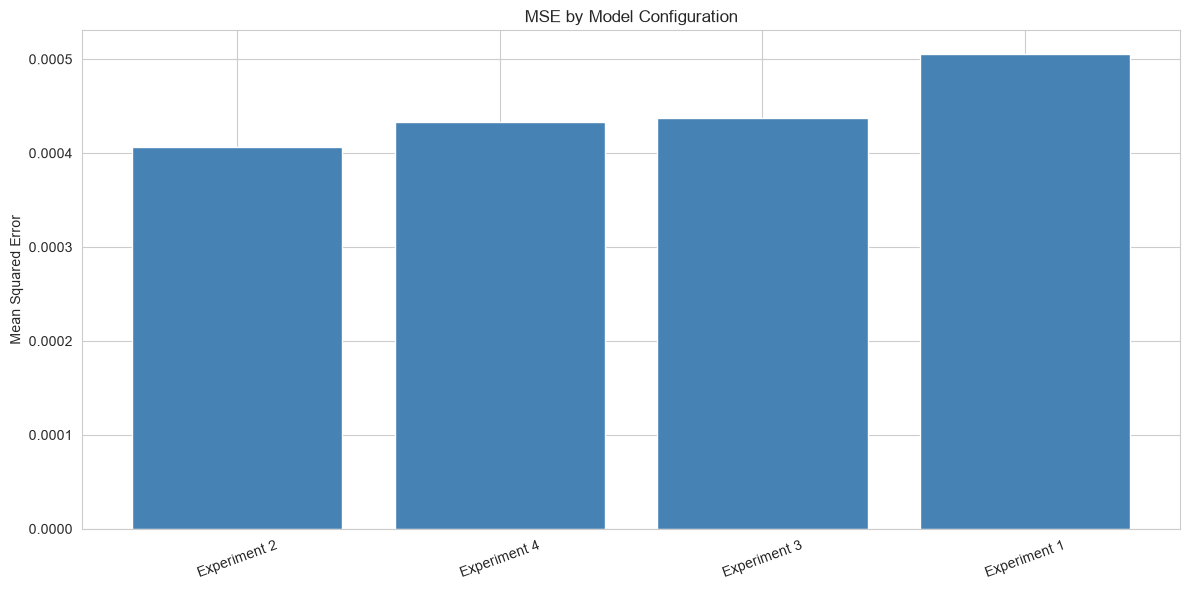

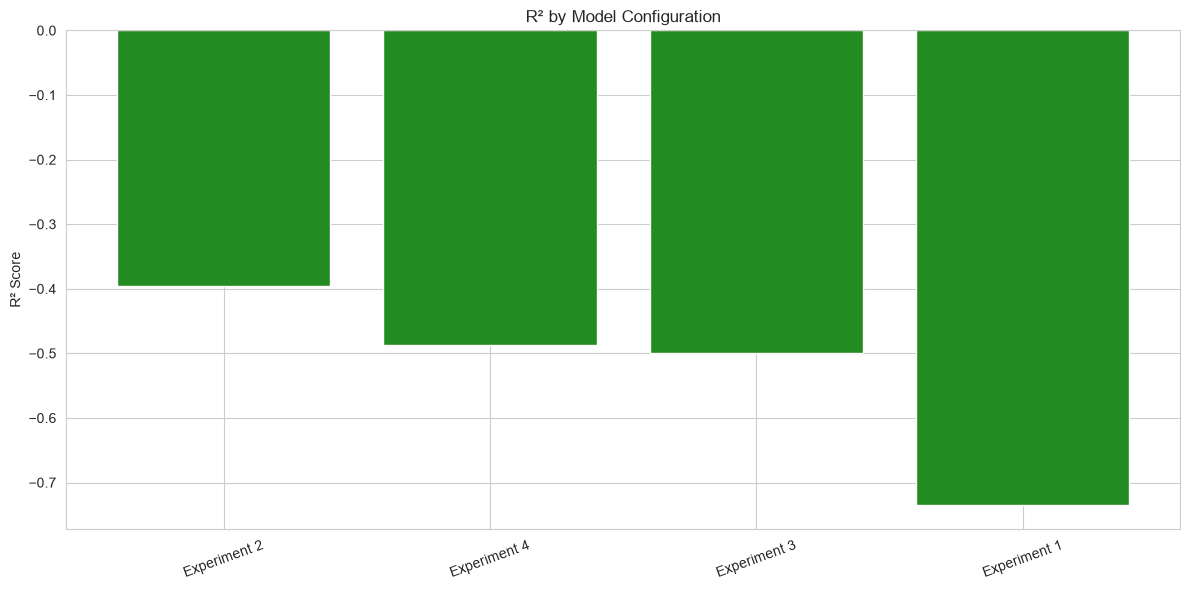

In [16]:
# A visual comparison of model performance by MSE and R².
comparison_df_sorted = comparison_df.sort_values('MSE').reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.bar(comparison_df_sorted['Model Configuration'], comparison_df_sorted['MSE'], color='steelblue')
plt.title('MSE by Model Configuration')
plt.ylabel('Mean Squared Error')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(comparison_df_sorted['Model Configuration'], comparison_df_sorted['R²'], color='forestgreen')
plt.title('R² by Model Configuration')
plt.ylabel('R² Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Final Conclusion

In this project, we built a machine learning model to predict the next day's daily stock return from lagged historical returns.

The results help us understand how the MLP behaves under different configurations:
- More epochs may improve learning, but can also lead to overfitting if pushed too far.
- More hidden layers can capture more complex relationships, but they also make the model harder to train and can reduce generalization.
- More neurons increase the model capacity, but larger networks may overfit if the dataset is limited.
- A model showing very low training error but poor test error is a sign of overfitting.

In practice, stock return prediction is extremely difficult because financial markets are noisy, non-stationary, and often driven by factors beyond past returns alone.
The notebook demonstrates a clean and educational workflow for building, evaluating, and comparing MLP regression models on a real stock dataset.

This project is a good starting point for exploring more advanced features, such as macroeconomic indicators, technical indicators, sentiment data, or alternative forecasting models.